In [1]:
import os
import pandas as pd
import numpy as np
from Bio.PDB import PDBParser, DSSP
from tmtools import tm_align # pip install tmtools
import subprocess
import tempfile
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
# ==========================================
# 1. 환경 설정 및 경로
# ==========================================
DSSP_EXE = "mkdssp"  # 또는 'dssp' (which mkdssp로 확인한 경로)

# 사용자 환경에 맞는 절대 경로로 수정하세요
CSV_PATH = "/data/esmdiff_target/EigenFold/splits/apo.csv"
DIR_GT_APO = "/data/esmdiff_target/EigenFold/structures/"
DIR_GT_HOLO = "/data/esmdiff_target/EigenFold/structures/"
DIR_OUR_MODEL = "/hierarchical_ConfGen/slm/models/residual_120K/apo_holo_pred/"
DIR_BASELINE = "/hierarchical_ConfGen/slm/models/esmdiff_baseline/reproduced_esmdiff_sampled5_apo1/"

In [ ]:
def get_ss_with_header_fix(pdb_path, model_idx):
    parser = PDBParser(QUIET=True)
    temp_path = None
    try:
        with tempfile.NamedTemporaryFile(mode='w', suffix='.pdb', delete=False) as tf:
            tf.write("CRYST1    1.000    1.000    1.000  90.00  90.00  90.00 P 1           1\n")
            with open(pdb_path, 'r') as original:
                tf.write(original.read())
            temp_path = tf.name

        structure = parser.get_structure("p", temp_path)
        model = structure[model_idx]
        dssp = DSSP(model, temp_path, dssp=DSSP_EXE)
        
        ss_map = {
            'H': 'H', 'G': 'H', 'I': 'H',
            'E': 'E', 'B': 'E',
            'T': 'C', 'S': 'C', '-': 'C', ' ': 'C'
        }
        
        raw_ss = [dssp[k][2] for k in dssp.keys()]
        q3_seq = "".join([ss_map.get(s, 'C') for s in raw_ss])
        
        return q3_seq

    except Exception as e:
        return ""
    finally:
        if temp_path and os.path.exists(temp_path):
            os.remove(temp_path)

def analyze_structure_pair(gt_path, pred_path, model_idx):
    """두 구조 간의 RMSD, TM-score, Q3 SS Accuracy 계산"""
    parser = PDBParser(QUIET=True)
    
    def get_ca_data(path, m_idx):
        try:
            s = parser.get_structure("p", path)[m_idx]
            coords, seq = [], ""
            for res in s.get_residues():
                if 'CA' in res:
                    coords.append(res['CA'].get_coord())
                    seq += "A"
            return np.array(coords).astype(np.float32), seq
        except: return None, None

    gt_coords, gt_seq = get_ca_data(gt_path, 0)
    pr_coords, pr_seq = get_ca_data(pred_path, model_idx)
    
    if gt_coords is None or pr_coords is None or len(gt_coords) == 0:
        return np.nan, np.nan, 0.0

    res = tm_align(pr_coords, gt_coords, pr_seq, gt_seq)
    
    tm_score = getattr(res, 'tm', getattr(res, 'tm_norm_a', np.nan))
    rmsd = res.rmsd
    
    gt_ss = get_ss_with_header_fix(gt_path, 0)
    pr_ss = get_ss_with_header_fix(pred_path, model_idx)
    
    min_len = min(len(gt_ss), len(pr_ss))
    if min_len > 0:
        matches = sum(1 for a, b in zip(gt_ss[:min_len], pr_ss[:min_len]) if a == b)
        ss_acc = (matches / min_len) * 100
    else:
        ss_acc = 0.0
    
    return rmsd, tm_score, ss_acc

In [ ]:
df = pd.read_csv(CSV_PATH)
final_results = []

for _, row in tqdm(df.iterrows()):
    p_name = row['name']
    h_name = row['holo']
    entry = {"name": p_name}
    
    paths = {
        "GT_Apo": os.path.join(DIR_GT_APO, f"{p_name[0:2]}/{p_name}"),
        "GT_Holo": os.path.join(DIR_GT_HOLO, f"{h_name[0:2]}/{h_name}"),
        "Our": os.path.join(DIR_OUR_MODEL, f"{p_name}"),
        "Base": os.path.join(DIR_BASELINE, f"{p_name}")
    }

    for gt_type in ["GT_Apo", "GT_Holo"]:
        for pred_type in ["Our", "Base"]:
            rmsd_list, tm_list, ss_list = [], [], []
            
            for i in range(5):
                r, t, s = analyze_structure_pair(paths[gt_type], paths[pred_type], i)
                if not np.isnan(r):
                    rmsd_list.append(r)
                    tm_list.append(t)
                    ss_list.append(s)
            
            label = f"{gt_type.split('_')[1]}_{pred_type}" # 예: Apo_Our
            entry[f"{label}_RMSD"] = np.min(rmsd_list) if rmsd_list else np.nan
            entry[f"{label}_TM"] = np.max(tm_list) if tm_list else np.nan
            entry[f"{label}_SS_Acc"] = np.mean(ss_list) if ss_list else 0.0

    final_results.append(entry)

output_df = pd.DataFrame(final_results)
output_df.to_csv("/hierarchical_ConfGen/slm/models/analysis/apo_analysis_Q3.csv", index=False)
print("result saved at '/hierarchical_ConfGen/slm/models/analysis/apo_analysis_Q3.csv'")

Protein 1ael.A.pdb 분석 완료
Protein 1bv2.A.pdb 분석 완료
Protein 1c54.A.pdb 분석 완료
Protein 1eal.A.pdb 분석 완료
Protein 1f3y.A.pdb 분석 완료
Protein 1fmf.A.pdb 분석 완료
Protein 1gh1.A.pdb 분석 완료
Protein 1gqn.A.pdb 분석 완료
Protein 1gqz.A.pdb 분석 완료
Protein 1hsi.B.pdb 분석 완료
Protein 1i56.A.pdb 분석 완료
Protein 1igp.A.pdb 분석 완료
Protein 1jfj.A.pdb 분석 완료
Protein 1k2h.A.pdb 분석 완료
Protein 1lip.A.pdb 분석 완료
Protein 1mut.A.pdb 분석 완료
Protein 1mx7.A.pdb 분석 완료
Protein 1ntr.A.pdb 분석 완료
Protein 1o1u.A.pdb 분석 완료
Protein 1pdb.A.pdb 분석 완료
Protein 1tfu.A.pdb 분석 완료
Protein 1tjd.A.pdb 분석 완료
Protein 1xsa.A.pdb 분석 완료
Protein 1z15.A.pdb 분석 완료
Protein 2cjo.A.pdb 분석 완료
Protein 2d9e.A.pdb 분석 완료
Protein 2f63.A.pdb 분석 완료
Protein 2fhm.A.pdb 분석 완료
Protein 2in2.A.pdb 분석 완료
Protein 2ju3.A.pdb 분석 완료
Protein 2jww.A.pdb 분석 완료
Protein 2k43.A.pdb 분석 완료
Protein 2l50.A.pdb 분석 완료
Protein 2l68.A.pdb 분석 완료
Protein 2lao.A.pdb 분석 완료
Protein 2lhs.A.pdb 분석 완료
Protein 2nln.A.pdb 분석 완료
Protein 2p3m.A.pdb 분석 완료
Protein 2uz5.A.pdb 분석 완료
Protein 4ake.B.pdb 분석 완료


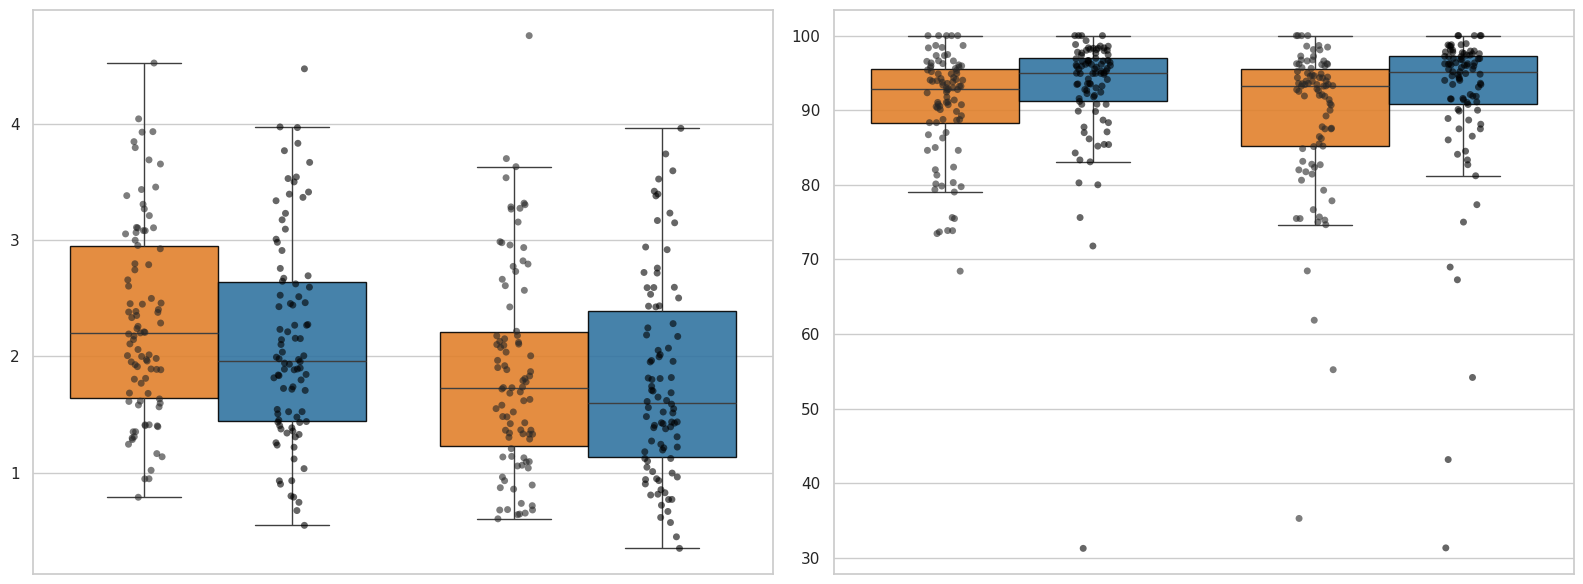


Mean & Median Summary
                 mean             median          
Model        Baseline Our Model Baseline Our Model
Metric State                                      
RMSD   Apo     2.2915    2.1234   2.1961    1.9630
       Holo    1.8563    1.7816   1.7299    1.5997
SS_Acc Apo    90.5291   92.7529  92.7958   94.9820
       Holo   89.1229   91.5571  93.2311   95.1613


In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

csv_file = "/hierarchical_ConfGen/slm/models/analysis/apo_analysis_Q3.csv"

if not os.path.exists(csv_file):
    print(f"error no csv file.")
else:
    df_raw = pd.read_csv(csv_file)

    target_metrics = ['RMSD', 'SS_Acc']
    states = ['Apo', 'Holo']
    methods = ['Base', 'Our']
    
    viz_list = []

    for _, row in df_raw.iterrows():
        for m in target_metrics:
            for st in states:
                for meth in methods:
                    col_name = f"{st}_{meth}_{m}"
                    
                    if col_name in df_raw.columns:
                        viz_list.append({
                            'Protein': row['name'],
                            'Metric': m,
                            'State': st,
                            'Model': 'Our Model' if meth == 'Our' else 'Baseline',
                            'Score': row[col_name]
                        })

    df_viz = pd.DataFrame(viz_list)

    if df_viz.empty:
        print("error check the mapping in csv file")
    else:
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # ==========================================
        # [수정] 순서 변경: Baseline -> Our Model
        # ==========================================
        # Our Model이 오른쪽으로 가도록 순서 배치
        my_order = ['Baseline', 'Our Model'] 
        
        # 색상 매핑 (순서가 바뀌어도 색상은 모델에 고정됨)
        my_palette = {
            'Our Model': '#1f77b4',  # 진한 파랑
            'Baseline':  '#ff7f0e'   # 진한 주황
        }
        
        # 투명도 및 테두리 (진하게)
        my_box_props = {'alpha': 0.9, 'edgecolor': 'black'} 

        for i, m_name in enumerate(target_metrics):
            sub_df = df_viz[df_viz['Metric'] == m_name]
            
            # Boxplot
            sns.boxplot(
                ax=axes[i], 
                data=sub_df, 
                x='State', 
                y='Score', 
                hue='Model', 
                hue_order=my_order,     # [수정] 바뀐 순서 적용
                palette=my_palette,     
                showfliers=False, 
                boxprops=my_box_props   
            )
            
            # Stripplot
            sns.stripplot(
                ax=axes[i], 
                data=sub_df, 
                x='State', 
                y='Score', 
                hue='Model',
                hue_order=my_order,     # [수정] 점들도 바뀐 순서 적용
                dodge=True, 
                alpha=0.6, 
                size=5, 
                jitter=True,
                palette="dark:black",   
                legend=False            
            )
            
            # 텍스트/라벨/눈금 제거
            axes[i].set_title("")
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")
            #axes[i].tick_params(axis='both', which='both', labelbottom=False, labelleft=False, bottom=False, left=False)
            axes[i].set_xticklabels([]) 
            
            if axes[i].get_legend() is not None:
                axes[i].get_legend().remove()

        plt.tight_layout()
        plt.show()

        print("\n" + "="*80)
        print("Mean & Median Summary")
        print("="*80)
        
        summary = df_viz.groupby(['Metric', 'State', 'Model'])['Score'].agg(['mean', 'median']).unstack()
        # 요약표도 Baseline -> Our Model 순서로 정렬
        if 'Baseline' in summary.columns.get_level_values(1):
             summary = summary.reindex(columns=my_order, level=1)
             
        pd.set_option('display.float_format', '{:.4f}'.format)
        print(summary)